In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Sampled Dataset
data_path = r"C:\Users\SUJATA\Desktop\Data\Data Science\spotify_sample_10000.csv"
df = pd.read_csv(data_path)

print(f"Dataset successfully loaded for classification. Shape: {df.shape}")


Dataset successfully loaded for classification. Shape: (10000, 20)


In [2]:
# Calculate the middle split mark for popularity
median_popularity = df['popularity'].median()

# Create the binary target column: 1 for a Hit, 0 for a Non-Hit
df['is_hit'] = (df['popularity'] > median_popularity).astype(int)

print(f"Popularity Median Threshold: {median_popularity}")
print(df['is_hit'].value_counts())


Popularity Median Threshold: 35.0
is_hit
0    5115
1    4885
Name: count, dtype: int64


In [3]:
features = ['danceability', 'energy', 'liveness']

X = df[features]
y = df['is_hit']

# Perform a reproducible 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training classification features shape : {X_train.shape}")
print(f"Testing classification features shape  : {X_test.shape}")


Training classification features shape : (7000, 3)
Testing classification features shape  : (3000, 3)


In [4]:
# Initialise the Logistic Regression classifier
classifier = LogisticRegression(random_state=42)

# Train the classifier on the training data
classifier.fit(X_train, y_train)

# Generate class predictions on the test dataset
y_pred = classifier.predict(X_test)

print("Classifier training and prediction steps successfully completed.")


Classifier training and prediction steps successfully completed.


In [5]:
# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

print("--- Logistic Regression Evaluation ---")
print(f"Model Accuracy: {accuracy:.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Hit', 'Hit']))


--- Logistic Regression Evaluation ---
Model Accuracy: 0.5110

Detailed Classification Report:
              precision    recall  f1-score   support

     Non-Hit       0.52      0.57      0.55      1535
         Hit       0.50      0.44      0.47      1465

    accuracy                           0.51      3000
   macro avg       0.51      0.51      0.51      3000
weighted avg       0.51      0.51      0.51      3000



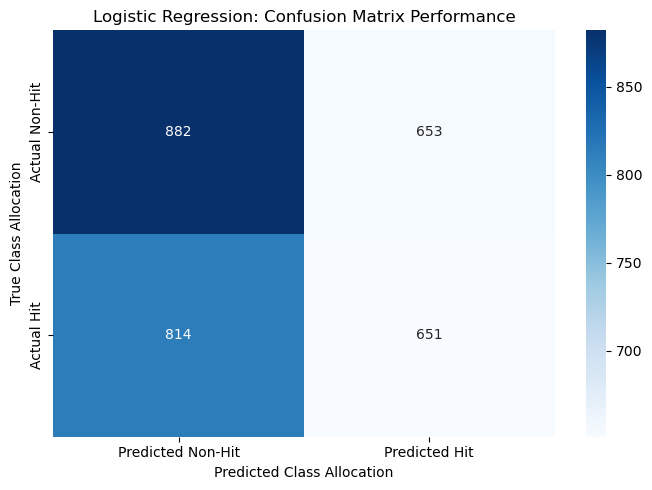

In [6]:
# Generate the matrix grid values
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

# Draw the heatmap matrix plot with whole numbers
sns.heatmap(
    matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Predicted Non-Hit', 'Predicted Hit'], 
    yticklabels=['Actual Non-Hit', 'Actual Hit']
)

plt.title('Logistic Regression: Confusion Matrix Performance')
plt.ylabel('True Class Allocation')
plt.xlabel('Predicted Class Allocation')
plt.tight_layout()

# Save the confusion matrix plot directly to your local project folder
plt.savefig(r"C:\Users\SUJATA\Desktop\Data\Data Science\confusion_matrix.png", dpi=300)
plt.show()
